# Bike Deal Classifier

**Goal:** Classify Finn.no bike listings as *good deal*, *ok deal*, or *bad deal* using a price-deviation approach.

**Strategy:**
1. Extract features from the listing (groupset tier, condition, carbon frame, brand, etc.)
2. Train a regression model to predict the *expected market price* from those features
3. Label each listing based on how far its actual price deviates from the expected price
4. Use those labels to train a final classification model

**Pipeline overview:**
```
Raw CSV → Preprocessing → Feature engineering → Price regression → Labels → Classifier
```

## 0. Setup

In [75]:
# Install if needed
# !pip install pandas numpy scikit-learn matplotlib seaborn xgboost

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_predict, KFold
from sklearn.metrics import r2_score, mean_absolute_error
from xgboost import XGBRegressor

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 60)

## 1. Load data

In [76]:
DATA_PATH = '../data/finn_ad_data.csv'

df = pd.read_csv(DATA_PATH, dtype=str)
print(f'Shape: {df.shape}')
df.head(3)

Shape: (730, 20)


,ad_id,source_url,scraped_at,title,price_nok,tilstand,merke,kjonn,sykkeltype,brand,model,year,framesize,wheel_size,groupset,carbon_frame,carbon_wheels,electronic_shifting,description,location
0,450736924,https://www.finn.no/recommerce/forsale/item/450736924,2026-03-02T15:24:19.843Z,CANYON Aeroad CF SLX 8.0 DI2,52000,Som ny - Ikke synlig brukt,Canyon,Unisex,Landevei,Canyon,Aeroad CF SLX 8.0 Di2,NaN,L,NaN,Shimano Ultegra Di2,true,true,true,Nydelig CANYON Aeroad CF SLX 8.0 DI2 luftes for salg med...,5582 Ølensvåg
1,413731731,https://www.finn.no/recommerce/forsale/item/413731731,2026-03-02T15:24:36.501Z,BMC TEAM MACHINE SLR FOUR - SYKKELPAKKE MED WAHOO KICKR ...,45000,Pent brukt - I god stand,Andre merker,Herre,Landevei,BMC,Teammachine SLR Four,NaN,58,700c,SRAM Rival AXS,true,false,true,Fantastisk sykkel med masse tilbehør søker ny eier. Den ...,3121 Nøtterøy
2,453463150,https://www.finn.no/recommerce/forsale/item/453463150,2026-03-02T15:24:37.732Z,Trek Madone Two Series landeveissykkel 52 cm unisex rød,7000,Pent brukt - I god stand,Trek,Unisex,Landevei,Trek,Madone Two Series,NaN,52cm,700c,Shimano,false,false,false,Trek Madone Two Series landeveissykkel i unisex-størrels...,7506 Stjørdal


In [77]:
# Overview: dtypes and missing values
missing = df.isnull().sum().rename('missing')
empty  = (df == '').sum().rename('empty_str')
pd.concat([missing, empty], axis=1).assign(
    total_missing=lambda x: x['missing'] + x['empty_str'],
    pct=lambda x: (x['total_missing'] / len(df) * 100).round(1)
).sort_values('total_missing', ascending=False)

,missing,empty_str,total_missing,pct
year,446,0,446,61.1
wheel_size,415,0,415,56.8
merke,312,0,312,42.7
groupset,196,0,196,26.8
kjonn,182,0,182,24.9
framesize,122,0,122,16.7
model,92,0,92,12.6
tilstand,46,0,46,6.3
brand,24,0,24,3.3
price_nok,2,0,2,0.3


## 2. Preprocessing

### 2.1 Price

Rows with missing price:  2
Price range: 102 – 681,052,202,560,000 NOK


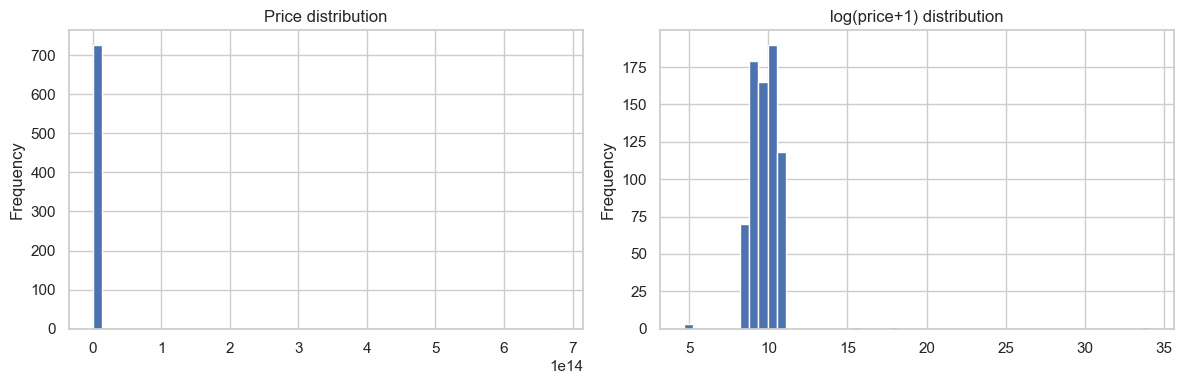

In [78]:
df['price_nok'] = pd.to_numeric(df['price_nok'], errors='coerce')

print(f'Rows with missing price:  {df["price_nok"].isna().sum()}')
print(f'Price range: {df["price_nok"].min():,.0f} – {df["price_nok"].max():,.0f} NOK')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['price_nok'].dropna().plot.hist(bins=50, ax=axes[0], title='Price distribution')
np.log1p(df['price_nok'].dropna()).plot.hist(bins=50, ax=axes[1], title='log(price+1) distribution')
plt.tight_layout()

In [79]:
# Drop rows without a price — can't label or train without it
df = df.dropna(subset=['price_nok']).copy()

# Sanity filter: keep plausible road bike prices (500 – 250 000 NOK)
df = df[(df['price_nok'] >= 500) & (df['price_nok'] <= 250_000)].copy()
print(f'Rows after price filter: {len(df)}')

Rows after price filter: 722


### 2.2 Condition (tilstand) → ordinal score

In [80]:
print(df['tilstand'].value_counts(dropna=False).to_string())

tilstand
Pent brukt - I god stand                   469
Som ny - Ikke synlig brukt                 126
Godt brukt - Synlig brukt                   57
NaN                                         46
Helt ny - Uåpnet/med lapp                   21
Må fikses - Noen mangler/ødelagte deler      3


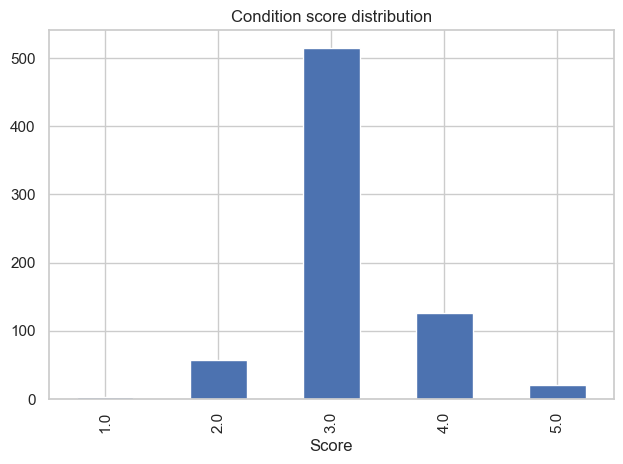

In [81]:
CONDITION_MAP = {
    'Helt ny - Uåpnet/med lapp':   5,
    'Som ny - Ikke synlig brukt':   4,
    'Pent brukt - I god stand':     3,
    'Godt brukt - Synlig brukt':    2,
    'Må fikses - Noen mangler/ødelagte deler':  1,
}

df['condition_score'] = df['tilstand'].map(CONDITION_MAP)

# Fill unknowns with the median
median_cond = df['condition_score'].median()
df['condition_score'] = df['condition_score'].fillna(median_cond)

df['condition_score'].value_counts().sort_index().plot.bar(title='Condition score distribution')
plt.xlabel('Score'); plt.tight_layout()

### 2.3 Groupset → tier (1–5)

In [82]:
print(df['groupset'].value_counts(dropna=False).head(30).to_string())

groupset
NaN                        194
Shimano Ultegra Di2         97
Shimano Ultegra             72
Shimano 105                 53
Shimano 105 Di2             34
Shimano Dura-Ace            21
SRAM Force AXS              11
SRAM Red                    10
Shimano                     10
Shimano 105 R7000           10
Shimano Tiagra              10
Shimano Dura-Ace Di2        10
SRAM Rival eTap AXS          9
Shimano Dura Ace             7
Campagnolo Record            7
SRAM Rival AXS               7
Campagnolo                   6
Shimano Di2                  6
Shimano Dura Ace Di2         5
SRAM Force                   5
Shimano 105 R7100            5
SRAM Red eTap                5
Shimano Ultegra R8000        4
SRAM Force eTap AXS          4
Shimano Ultegra/105          4
SRAM Rival                   3
Shimano Ultegra Di2 12s      3
Shimano Ultegra 6800         3
Shimano Claris               3
Shimano Sora                 3


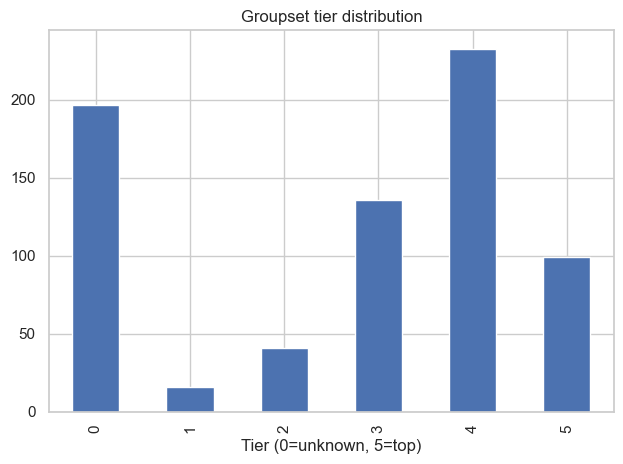

In [83]:
def groupset_tier(gs: str) -> int:
    """
    Returns an integer tier (1–5) for a groupset string.
    Higher = better / more expensive.
    0 = unknown.
    """
    if not isinstance(gs, str) or gs.strip() == '':
        return 0
    g = gs.lower()

    # Tier 5 — top-of-the-line
    if any(k in g for k in ['dura-ace', 'dura ace', 'duraace',
                              'sram red', 'super record', 'record']):
        return 5

    # Tier 4 — high-end
    if any(k in g for k in ['ultegra', 'force', 'chorus', 'athena']):
        return 4

    # Tier 3 — mid-range
    if any(k in g for k in ['105', 'rival', 'centaur', 'veloce']):
        return 3

    # Tier 2 — entry sport
    if any(k in g for k in ['tiagra', 'apex', 'potenza', 'xenon']):
        return 2

    # Tier 1 — entry level
    if any(k in g for k in ['sora', 'claris', 'tourney', 'acera', 'campagnolo']):
        return 1

    # Generic shimano / other named group with no tier match
    if 'shimano' in g or 'sram' in g or 'campagnolo' in g:
        return 2  # at least a real group

    return 0  # truly unknown


df['groupset_tier'] = df['groupset'].apply(groupset_tier)
df['groupset_tier'].value_counts().sort_index().plot.bar(title='Groupset tier distribution')
plt.xlabel('Tier (0=unknown, 5=top)'); plt.tight_layout()

### 2.4 Boolean features

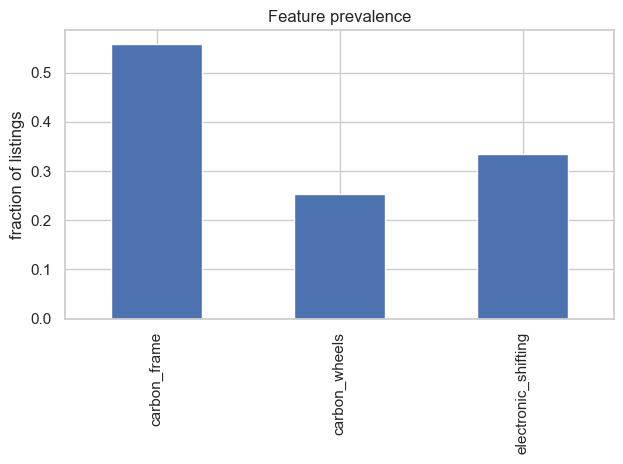

In [84]:
for col in ['carbon_frame', 'carbon_wheels', 'electronic_shifting']:
    df[col] = df[col].map({'true': 1, 'false': 0}).fillna(0).astype(int)

df[['carbon_frame', 'carbon_wheels', 'electronic_shifting']].mean().plot.bar(
    title='Feature prevalence', ylabel='fraction of listings')
plt.tight_layout()

### 2.5 Brand → tier (1–4)

In [85]:
print(df['brand'].value_counts(dropna=False).head(25).to_string())

brand
Trek           69
Cannondale     47
Scott          47
Giant          44
Specialized    42
Canyon         41
Bianchi        35
Merida         33
Orbea          25
NaN            24
Ridley         24
White          12
Dare           11
Vipera         11
Gavia          11
BMC            10
Pinarello      10
Colnago        10
Wilier          8
Eddy Merckx     8
Diamant         7
Peugeot         7
Cube            7
Jamis           6
DBS             6


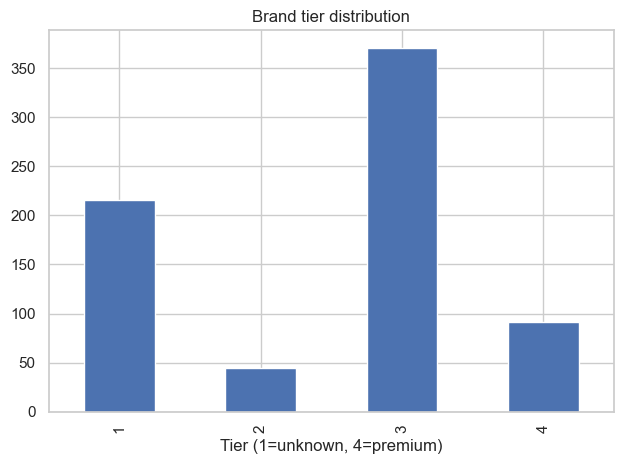

In [86]:
# Premium / pro-tour brands
BRAND_TIER_4 = {
    'pinarello', 'colnago', 'cervelo', 'bmc', 'wilier', 'look', 'time', 'de rosa',
    'specialized',  # S-Works models show up as brand='Specialized'
}
# Pro / performance brands
BRAND_TIER_3 = {
    'trek', 'cannondale', 'giant', 'canyon', 'bianchi', 'ridley', 'scott',
    'felt', 'cube', 'orbea', 'focus', 'lapierre', 'factor', 'rose', 'ktm',
    'eddy merckx', 'cinelli', 'fuji',
}
# Mid-range / enthusiast brands
BRAND_TIER_2 = {
    'merida', 'btwin', 'decathlon', 'raleigh', 'norco', 'marin', 'nakamura',
    'hardrocx', 'nor', 'nishiki',
}

def brand_tier(b: str) -> int:
    if not isinstance(b, str) or b.strip() == '':
        return 1
    b_lower = b.lower().strip()
    if b_lower in BRAND_TIER_4:
        return 4
    if b_lower in BRAND_TIER_3:
        return 3
    if b_lower in BRAND_TIER_2:
        return 2
    return 1  # unknown / other


df['brand_tier'] = df['brand'].apply(brand_tier)
df['brand_tier'].value_counts().sort_index().plot.bar(title='Brand tier distribution')
plt.xlabel('Tier (1=unknown, 4=premium)'); plt.tight_layout()

### 2.6 Year → bike age

Year known: 281 / 722


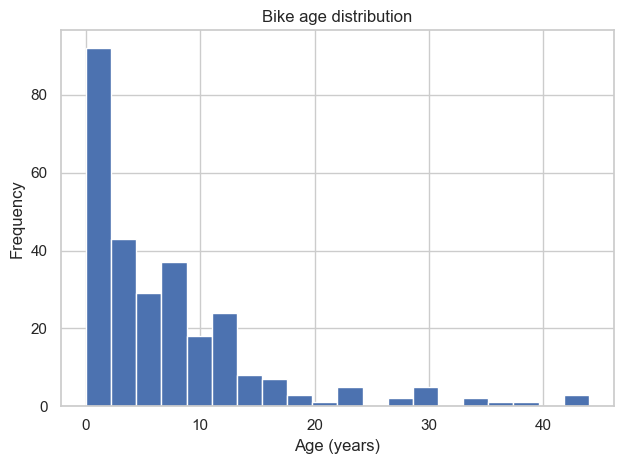

In [87]:
CURRENT_YEAR = 2026

df['year_num'] = pd.to_numeric(df['year'], errors='coerce')

# Sanity: only accept years between 1980 and current year
df.loc[(df['year_num'] < 1980) | (df['year_num'] > CURRENT_YEAR), 'year_num'] = np.nan

df['bike_age'] = CURRENT_YEAR - df['year_num']  # NaN if year unknown

print(f'Year known: {df["year_num"].notna().sum()} / {len(df)}')
df['bike_age'].dropna().plot.hist(bins=20, title='Bike age distribution')
plt.xlabel('Age (years)'); plt.tight_layout()

### 2.7 Frame size → numeric (cm)

In [88]:
print(df['framesize'].value_counts(dropna=False).head(20).to_string())

framesize
NaN       122
M          58
L          48
54         46
56         44
S          34
58         29
Medium     23
56cm       22
54cm       21
52         16
XL         15
M/L        14
XS         12
58cm       11
51         10
52cm        9
55          9
57cm        9
53cm        9


Frame size known: 570 / 722


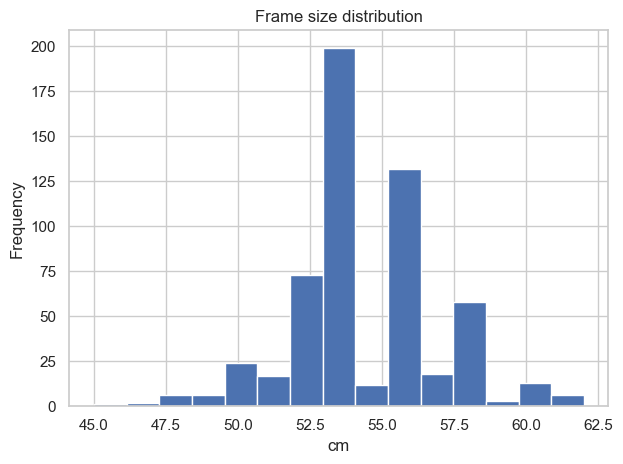

In [89]:
SIZE_LETTER_MAP = {
    'xxs': 48, 'xs': 50, 's': 52, 'small': 52,
    'm': 54, 'medium': 54,
    'l': 56, 'large': 56,
    'xl': 58, 'xlarge': 58, 'x-large': 58,
    'xxl': 60,
}

def parse_framesize(val: str):
    """Returns frame size in cm (float), or NaN."""
    if not isinstance(val, str) or val.strip() == '':
        return np.nan
    v = val.lower().strip()

    # Letter size with optional parenthetical, e.g. "Small (54)" → prefer numeric part
    m = re.search(r'\((\d{2,3})\)', v)
    if m:
        return float(m.group(1))

    # Numeric with optional unit: "54cm", "54 cm", "54"
    m = re.match(r'^(\d{2,3})\s*cm?$', v)
    if m:
        return float(m.group(1))

    # Pure number
    m = re.match(r'^(\d{2,3})$', v)
    if m:
        return float(m.group(1))

    # Letter size
    for key, cm in SIZE_LETTER_MAP.items():
        if v.startswith(key):
            return float(cm)

    return np.nan


df['framesize_cm'] = df['framesize'].apply(parse_framesize)

# Sanity: road bike frames are ~44–65 cm
df.loc[(df['framesize_cm'] < 44) | (df['framesize_cm'] > 65), 'framesize_cm'] = np.nan

print(f'Frame size known: {df["framesize_cm"].notna().sum()} / {len(df)}')
df['framesize_cm'].dropna().plot.hist(bins=15, title='Frame size distribution')
plt.xlabel('cm'); plt.tight_layout()

## 3. Feature engineering summary

In [90]:
FEATURES = [
    'condition_score',     # 0–5 ordinal
    'groupset_tier',       # 0–5 ordinal
    'brand_tier',          # 1–4 ordinal
    'carbon_frame',        # 0/1
    'carbon_wheels',       # 0/1
    'electronic_shifting', # 0/1
    'bike_age',            # years (NaN filled below)
    'framesize_cm',        # cm   (NaN filled below)
]

# Fill remaining NaNs with median for numeric features
for col in ['bike_age', 'framesize_cm']:
    df[col] = df[col].fillna(df[col].median())

X = df[FEATURES].copy()
y = df['price_nok'].copy()

print('Feature matrix shape:', X.shape)
X.describe().round(1)

Feature matrix shape: (722, 8)


,condition_score,groupset_tier,brand_tier,carbon_frame,carbon_wheels,electronic_shifting,bike_age,framesize_cm
count,722.0,722.0,722.0,722.0,722.0,722.0,722.0,722.0
mean,3.1,2.7,2.5,0.6,0.3,0.3,5.9,54.4
std,0.6,1.8,1.0,0.5,0.4,0.5,5.1,2.3
min,1.0,0.0,1.0,0.0,0.0,0.0,0.0,45.0
25%,3.0,0.0,1.0,0.0,0.0,0.0,5.0,54.0
50%,3.0,3.0,3.0,1.0,0.0,0.0,5.0,54.0
75%,3.0,4.0,3.0,1.0,1.0,1.0,5.0,56.0
max,5.0,5.0,4.0,1.0,1.0,1.0,44.0,62.0


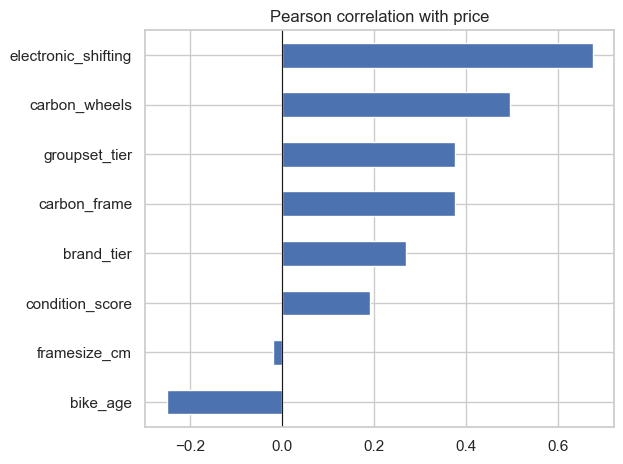

In [91]:
# Correlation with price
corr = X.assign(price_nok=y).corr()['price_nok'].drop('price_nok').sort_values()
corr.plot.barh(title='Pearson correlation with price')
plt.axvline(0, color='k', linewidth=0.8)
plt.tight_layout()

## 4. Price regression → labels

We train two regressors on **log-price** and compare them:
- **Random Forest** — robust ensemble, handles non-linearities well
- **XGBoost** — gradient-boosted trees, often more accurate with tabular data

Both use **out-of-fold (OOF) cross-validated predictions** so every listing's expected price is produced by a model that never trained on it — preventing leakage into the labels.

After comparing, we pick one set of predictions and label based on percentage deviation from expected price.

### 4.1 Random Forest

In [92]:
y_log = np.log1p(y)
cv    = KFold(n_splits=5, shuffle=True, random_state=42)

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=6,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1,
)

rf_log_pred = cross_val_predict(rf, X, y_log, cv=cv)
rf_pred     = np.expm1(rf_log_pred)

rf_r2  = r2_score(y, rf_pred)
rf_mae = mean_absolute_error(y, rf_pred)
print(f'[Random Forest]  OOF R²: {rf_r2:.3f}  |  MAE: {rf_mae:,.0f} NOK')

[Random Forest]  OOF R²: 0.565  |  MAE: 6,527 NOK


### 4.2 XGBoost

In [93]:
xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    verbosity=0,
)

xgb_log_pred = cross_val_predict(xgb, X, y_log, cv=cv)
xgb_pred     = np.expm1(xgb_log_pred)

xgb_r2  = r2_score(y, xgb_pred)
xgb_mae = mean_absolute_error(y, xgb_pred)
print(f'[XGBoost]        OOF R²: {xgb_r2:.3f}  |  MAE: {xgb_mae:,.0f} NOK')

[XGBoost]        OOF R²: 0.557  |  MAE: 6,550 NOK


### 4.3 Compare regressors

                  R²  MAE (NOK)
model                          
Random Forest  0.565       6527
XGBoost        0.557       6550


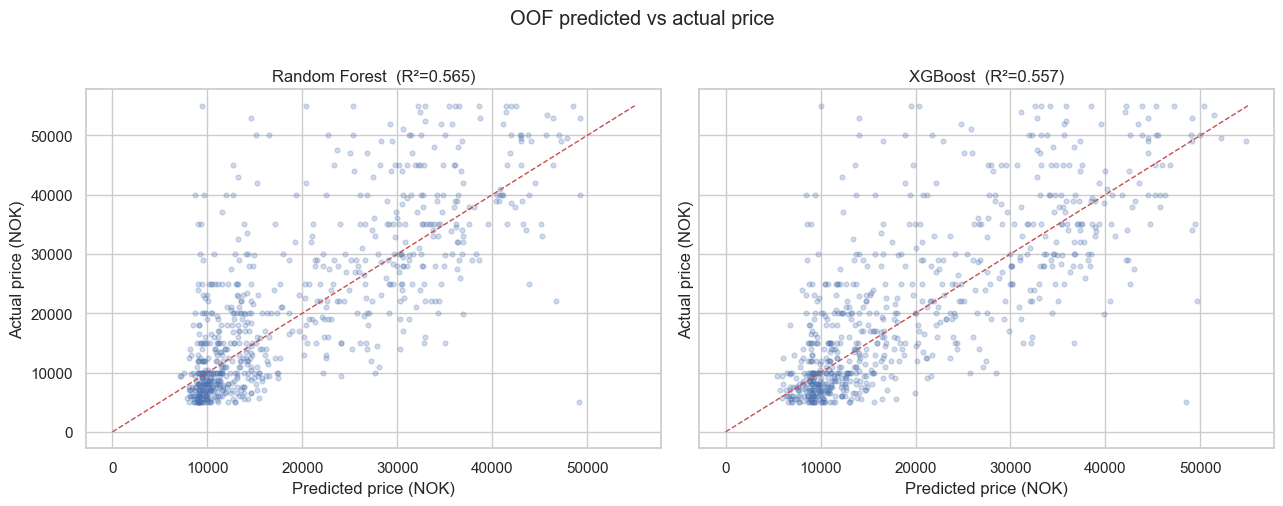

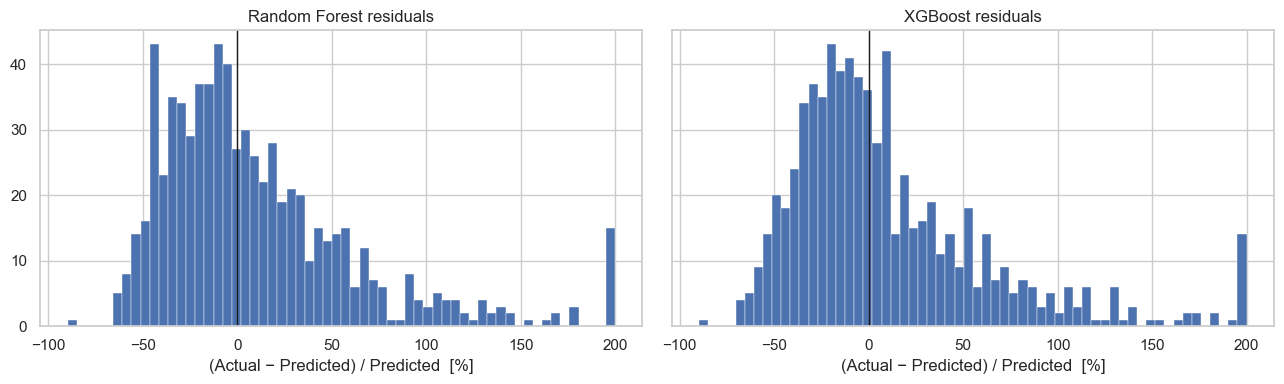

In [94]:
compare = pd.DataFrame([
    {'model': 'Random Forest', 'R²': rf_r2,  'MAE (NOK)': rf_mae},
    {'model': 'XGBoost',       'R²': xgb_r2, 'MAE (NOK)': xgb_mae},
]).set_index('model')
compare['MAE (NOK)'] = compare['MAE (NOK)'].round(0).astype(int)
compare['R²'] = compare['R²'].round(3)
print(compare.to_string())

# Scatter: predicted vs actual for both models
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
cap = max(y.max(), rf_pred.max(), xgb_pred.max())

for ax, preds, name in zip(axes, [rf_pred, xgb_pred], ['Random Forest', 'XGBoost']):
    ax.scatter(preds, y, alpha=0.25, s=12)
    ax.plot([0, cap], [0, cap], 'r--', linewidth=1)
    ax.set_xlabel('Predicted price (NOK)')
    ax.set_ylabel('Actual price (NOK)')
    ax.set_title(f'{name}  (R²={r2_score(y, preds):.3f})')

plt.suptitle('OOF predicted vs actual price', y=1.01)
plt.tight_layout()

# Residual distributions side by side
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for ax, preds, name in zip(axes, [rf_pred, xgb_pred], ['Random Forest', 'XGBoost']):
    resid_pct = (y - preds) / preds * 100
    ax.hist(resid_pct.clip(-100, 200), bins=60, edgecolor='white', linewidth=0.3)
    ax.axvline(0, color='k', linewidth=1)
    ax.set_xlabel('(Actual − Predicted) / Predicted  [%]')
    ax.set_title(f'{name} residuals')

plt.tight_layout()

### 4.4 Select model for labeling

Set `LABEL_MODEL` below to `'rf'` or `'xgb'` — whichever had the lower MAE above.  
The chosen predictions feed into the residual calculation and all downstream label cells.

In [95]:
LABEL_MODEL = 'xgb'   # ← change to 'rf' to use Random Forest instead

y_pred_oof = xgb_pred if LABEL_MODEL == 'xgb' else rf_pred
print(f'Using {LABEL_MODEL.upper()} predictions for labeling.')

Using XGB predictions for labeling.


### 4.5 Assign deal labels

We use **fixed percentage thresholds**:

| Label | Condition |
|---|---|
| `good_deal` | actual price < −20 % of predicted |
| `ok_deal`   | −20 % ≤ deviation ≤ +20 % |
| `bad_deal`  | actual price > +20 % of predicted |

Adjust the thresholds below if the class balance looks off.

In [96]:
# Residual = (actual – predicted) / predicted  (signed %)
df['price_predicted']   = y_pred_oof
df['price_residual_pct'] = (df['price_nok'] - df['price_predicted']) / df['price_predicted'] * 100

df['price_residual_pct'].describe().round(1)

count    722.0
mean      12.0
std       59.6
min      -89.7
25%      -25.0
50%       -3.2
75%       31.5
max      445.2
Name: price_residual_pct, dtype: float64

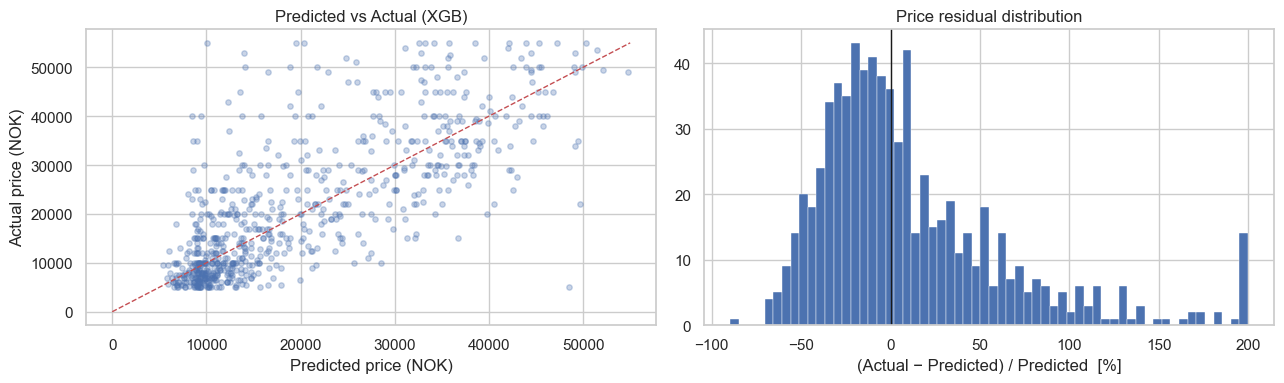

In [97]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].scatter(df['price_predicted'], df['price_nok'], alpha=0.3, s=15)
m = max(df['price_predicted'].max(), df['price_nok'].max())
axes[0].plot([0, m], [0, m], 'r--', linewidth=1)
axes[0].set_xlabel('Predicted price (NOK)')
axes[0].set_ylabel('Actual price (NOK)')
axes[0].set_title(f'Predicted vs Actual ({LABEL_MODEL.upper()})')

axes[1].hist(df['price_residual_pct'].clip(-100, 200), bins=60, edgecolor='white', linewidth=0.3)
axes[1].axvline(0, color='k', linewidth=1)
axes[1].set_xlabel('(Actual − Predicted) / Predicted  [%]')
axes[1].set_title('Price residual distribution')

plt.tight_layout()

deal_label
ok_deal      274
bad_deal     225
good_deal    223
Name: count, dtype: int64


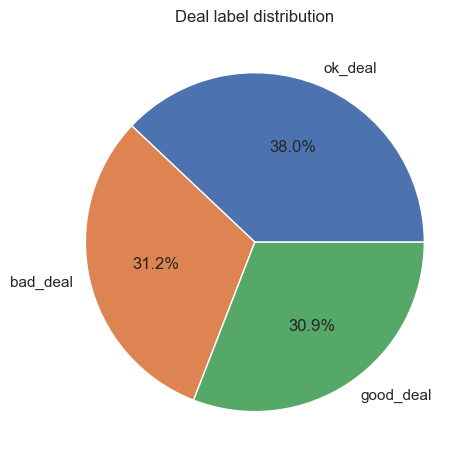

In [98]:
GOOD_THRESHOLD = -20   # % below predicted → good deal
BAD_THRESHOLD  = +20   # % above predicted → bad deal

def assign_label(pct):
    if pct < GOOD_THRESHOLD:
        return 'good_deal'
    elif pct > BAD_THRESHOLD:
        return 'bad_deal'
    return 'ok_deal'

df['deal_label'] = df['price_residual_pct'].apply(assign_label)

counts = df['deal_label'].value_counts()
print(counts)
counts.plot.pie(autopct='%1.1f%%', title='Deal label distribution')
plt.ylabel('')
plt.tight_layout()

In [99]:
# If classes are too imbalanced, try quantile-based thresholds instead:
# q33 = df['price_residual_pct'].quantile(0.33)
# q67 = df['price_residual_pct'].quantile(0.67)
# df['deal_label'] = pd.cut(df['price_residual_pct'],
#                            bins=[-np.inf, q33, q67, np.inf],
#                            labels=['good_deal', 'ok_deal', 'bad_deal'])
# print(df['deal_label'].value_counts())

## 5. Exploratory analysis of labels

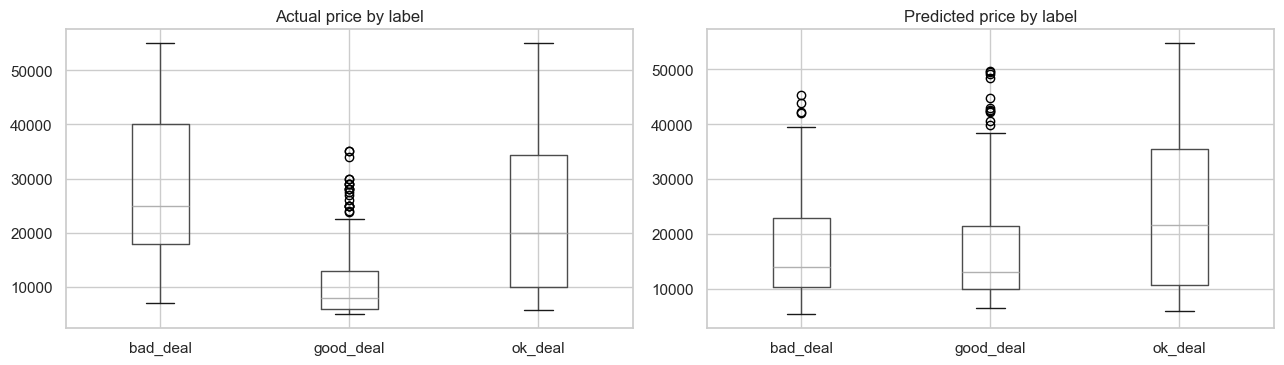

In [100]:
# Price by label
order = ['good_deal', 'ok_deal', 'bad_deal']
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

df.boxplot('price_nok', by='deal_label', ax=axes[0])
axes[0].set_title('Actual price by label')
axes[0].set_xlabel('')

df.boxplot('price_predicted', by='deal_label', ax=axes[1])
axes[1].set_title('Predicted price by label')
axes[1].set_xlabel('')

plt.suptitle('')
plt.tight_layout()

In [101]:
# Feature means per label
df.groupby('deal_label')[FEATURES].mean().round(2).T.style.background_gradient(axis=1, cmap='RdYlGn')

deal_label,bad_deal,good_deal,ok_deal
condition_score,3.140000,3.070000,3.210000
groupset_tier,2.690000,2.350000,2.930000
brand_tier,2.530000,2.340000,2.510000
carbon_frame,0.540000,0.470000,0.650000
carbon_wheels,0.230000,0.200000,0.320000
electronic_shifting,0.300000,0.220000,0.460000
bike_age,5.870000,6.090000,5.750000
framesize_cm,54.320000,54.450000,54.460000


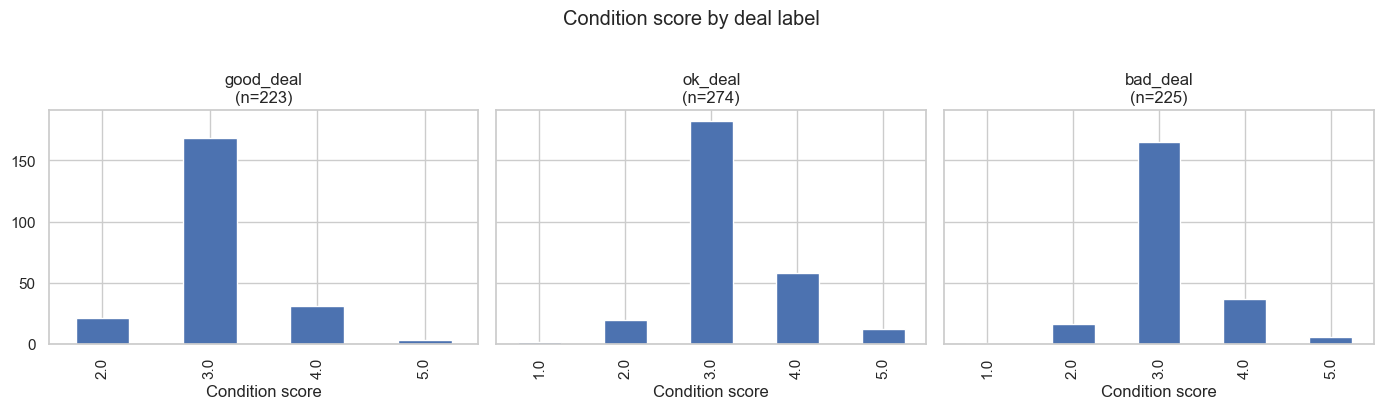

In [102]:
# Condition score distribution per label
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, label in zip(axes, order):
    subset = df[df['deal_label'] == label]
    subset['condition_score'].value_counts().sort_index().plot.bar(ax=ax)
    ax.set_title(f'{label}\n(n={len(subset)})')
    ax.set_xlabel('Condition score')
plt.suptitle('Condition score by deal label', y=1.02)
plt.tight_layout()

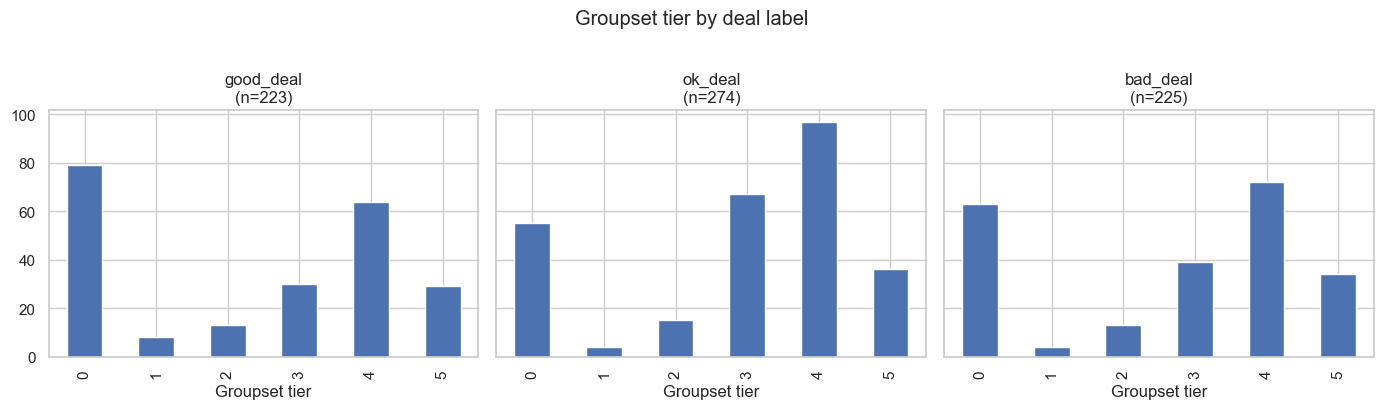

In [103]:
# Groupset tier distribution per label
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, label in zip(axes, order):
    subset = df[df['deal_label'] == label]
    subset['groupset_tier'].value_counts().sort_index().plot.bar(ax=ax)
    ax.set_title(f'{label}\n(n={len(subset)})')
    ax.set_xlabel('Groupset tier')
plt.suptitle('Groupset tier by deal label', y=1.02)
plt.tight_layout()

## 6. Inspect examples

Sanity check: do the labels make intuitive sense?

In [104]:
DISPLAY_COLS = ['title', 'price_nok', 'price_predicted', 'price_residual_pct',
                'deal_label', 'tilstand', 'brand', 'groupset',
                'carbon_frame', 'electronic_shifting']

print('=== TOP GOOD DEALS ===')
display(df[df['deal_label'] == 'good_deal']
        .sort_values('price_residual_pct')
        .head(10)[DISPLAY_COLS]
        .assign(price_residual_pct=lambda x: x['price_residual_pct'].round(1)))

=== TOP GOOD DEALS ===


,title,price_nok,price_predicted,price_residual_pct,deal_label,tilstand,brand,groupset,carbon_frame,electronic_shifting
70,Argon 18 E119 2025 modell - Utleie,5000.0,48468.109375,-89.7,good_deal,Som ny - Ikke synlig brukt,Argon 18,Shimano Ultegra Di2 R8150,1,1
249,Landeveissykel,5500.0,17956.548828,-69.4,good_deal,Pent brukt - I god stand,NaN,NaN,0,0
84,Fin sykkel selges,5100.0,15672.835938,-67.5,good_deal,Pent brukt - I god stand,Fixie Inc,NaN,0,0
140,"Meget pen italiensk banesykkel: Wilier Pista, str. S/M (...",6500.0,19903.416016,-67.3,good_deal,Som ny - Ikke synlig brukt,Wilier,NaN,0,0
514,Specialized Tarmac SL3 Expert Double,5500.0,16522.812500,-66.7,good_deal,NaN,Specialized,NaN,1,0
358,Karbon Nakamura Pursuit 7.0 med el. girsystem Shimano Ul...,10000.0,28498.771484,-64.9,good_deal,Som ny - Ikke synlig brukt,Nakamura,Shimano Ultegra 6800 Di2,1,1
169,Scott CR1 Team str. 54,5000.0,13125.839844,-61.9,good_deal,Pent brukt - I god stand,Scott,Shimano 105,1,0
39,Specialized Dolce sport,5000.0,13016.496094,-61.6,good_deal,Pent brukt - I god stand,Specialized,NaN,0,0
28,Giant TCR Racersykkel,5500.0,14235.091797,-61.4,good_deal,Pent brukt - I god stand,Giant,Shimano 105,1,0
334,Specialized S-works roubaix ramme 56/ L,10000.0,25690.498047,-61.1,good_deal,Helt ny - Uåpnet/med lapp,Specialized,NaN,1,0


In [105]:
print('=== TOP BAD DEALS ===')
display(df[df['deal_label'] == 'bad_deal']
        .sort_values('price_residual_pct', ascending=False)
        .head(10)[DISPLAY_COLS]
        .assign(price_residual_pct=lambda x: x['price_residual_pct'].round(1)))

=== TOP BAD DEALS ===


,title,price_nok,price_predicted,price_residual_pct,deal_label,tilstand,brand,groupset,carbon_frame,electronic_shifting
103,"Date VSRu Team edition, S, ARC 1400",55000.0,10088.616211,445.2,bad_deal,Pent brukt - I god stand,Dare,NaN,0,0
431,Ønsker å kjøpe 2x landeveissykkel str 49-51 og 54-56.,40000.0,8503.326172,370.4,bad_deal,Pent brukt - I god stand,NaN,NaN,0,0
36,Par søker par!,40000.0,9444.940430,323.5,bad_deal,Pent brukt - I god stand,Giant,NaN,0,0
475,Ny Cipollini Ad one Limited Edition ramme str XL selges ...,35000.0,8578.908203,308.0,bad_deal,NaN,Cipollini,NaN,0,0
228,Landeveissykkel ønsket kjøpt,35000.0,9034.876953,287.4,bad_deal,NaN,NaN,NaN,0,0
609,Giant TCR M/L Advanced 0 Compact 2021,53000.0,14035.944336,277.6,bad_deal,Pent brukt - I god stand,Giant,Shimano Ultegra,1,0
496,Scott Foil RC Pro,50000.0,14086.368164,255.0,bad_deal,Pent brukt - I god stand,Scott,Shimano Ultegra,1,0
418,"Canyon Landevei Sykkel S 28""/700c Unisex",43000.0,12300.033203,249.6,bad_deal,Pent brukt - I god stand,Canyon,SRAM Force,0,0
343,Landeveisykkel - Argon 18- meget lett sykkel,29000.0,8620.074219,236.4,bad_deal,Pent brukt - I god stand,Argon 18,Shimano Dura-Ace,1,0
185,Colnago v4rs rammesett,45000.0,13603.346680,230.8,bad_deal,Som ny - Ikke synlig brukt,Colnago,NaN,1,0


## 7. Save preprocessed dataset

In [106]:
OUT_PATH = '../data/finn_preprocessed.csv'

save_cols = ['ad_id', 'source_url', 'title', 'price_nok', 'price_predicted',
             'price_residual_pct', 'deal_label'] + FEATURES + ['tilstand', 'brand', 'groupset']

df[save_cols].to_csv(OUT_PATH, index=False)
print(f'Saved {len(df)} rows → {OUT_PATH}')
print(df['deal_label'].value_counts())

Saved 722 rows → ../data/finn_preprocessed.csv
deal_label
ok_deal      274
bad_deal     225
good_deal    223
Name: count, dtype: int64


---

## Next steps

The preprocessed file with labels is ready. The natural next notebook is:

1. **Train a classifier** (Random Forest, XGBoost, or a simple logistic regression) on `X` → `deal_label`
2. Evaluate with stratified k-fold (confusion matrix, classification report)
3. Inspect feature importances
4. Optionally: add text features from `description` (TF-IDF or a small embedding)
5. Export the trained classifier to score new listings in real time